In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_DIR = "/content/drive/MyDrive/SIT319_Ass3"
DATA_DIR = os.path.join(PROJECT_DIR, "data")
os.makedirs(DATA_DIR, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Data folder:", DATA_DIR)
os.makedirs(DATA_DIR, exist_ok=True)

Project folder: /content/drive/MyDrive/SIT319_Ass3
Data folder: /content/drive/MyDrive/SIT319_Ass3/data


## Environment and imports

In [3]:
# Replace or extend as needed
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Reproducibility

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print(f"Seed set to {SEED}")

Seed set to 42


Define the problem and dataset

**Problem summary**

Recycling contamination happens when the wrong material ends up in the bin, and that is basically why councils end up rejecting or landfilling loads that could have been recycled. So this project builds an image classifier that looks at a single photo of a waste item and works out what material it is, cardboard, glass, metal, paper or plastic, so sorting decisions become a bit clearer and more consistent at the point where someone actually throws it away. The model takes one RGB photo as input and returns a predicted class. We trained and evaluated it on a public garbage classification dataset using a pretrained MobileNetV2 CNN, mostly because it trains faster on Colab than something heavier like ResNet18, and we kept this same structure while only changing the augmentation and generalisation side of things.

**Problem setup table**

| Item | Your response |
| --- | --- |
| Recycling objective | Classify a photographed waste item by material, so contamination in the recycling bin can be reduced |
| Input image type | Single object RGB photo, different original resolutions, resized to 224×224 before training |
| Target classes | Cardboard, glass, metal, paper and plastic, five classes total |
| Dataset source(s) | Kaggle's Garbage Classification dataset (asdasdasasdas/garbage-classification), which is based on TrashNet |
| Whether additional manual labelling was required | No, we used the folder labels that already came with the dataset. The original sixth class, trash, was dropped because it was small and did not really represent one clear material |
| Total number of images | Around 2390 once trash was removed, but this number gets confirmed once the data is actually loaded |
| Train / validation / test split | 70% / 15% / 15%, stratified so each class keeps roughly the same share across all three splits |
| Success criteria | Baseline macro F1 should clearly beat random guessing, which sits around 0.20 for five classes, and the targeted improvement in Task 3 should measurably close the gap between the original test set and the new domain set |

In [6]:
import kagglehub
import os

# downloads the dataset once and caches it, returns the local folder path
dataset_path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")
print("Dataset downloaded to:", dataset_path)

# the actual images sit one level deeper inside this folder, find it
for root, dirs, files in os.walk(dataset_path):
    if len(dirs) >= 5:  # this is the folder that has our class subfolders
        data_root = root
        break

print("Class folders found in:", data_root)
print(os.listdir(data_root))

Using Colab cache for faster access to the 'garbage-classification' dataset.
Dataset downloaded to: /kaggle/input/garbage-classification
Class folders found in: /kaggle/input/garbage-classification/Garbage classification/Garbage classification
['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']


In [7]:
import shutil

target_path = os.path.join(DATA_DIR, "garbage-classification")
if not os.path.exists(target_path):
    shutil.copytree(data_root, target_path)
    print("Copied dataset to:", target_path)
else:
    print("Dataset already exists at:", target_path)

Dataset already exists at: /content/drive/MyDrive/SIT319_Ass3/data/garbage-classification


Baseline model

**Model choice and training setup**

For the baseline I used MobileNetV2 with pretrained ImageNet weights, and only replaced the final classifier layer so it outputs five classes instead of a thousand. I picked pretrained weights over training from scratch because the dataset is fairly small, just over two thousand images, and training a CNN from scratch on that would likely underfit or take a lot longer to get anywhere useful. Images were resized to 224x224 and normalised using the standard ImageNet mean and std, since that matches what the pretrained weights expect. I used the Adam optimiser with a learning rate of 1e-4, batch size of 32, and trained for 10 epochs, saving the checkpoint with the best validation macro-F1 rather than just the last epoch, since validation performance bounced around a bit across epochs on this small dataset. Cross entropy loss was used since this is a standard multi class single label problem.

**Baseline results**

| Metric | Validation | Test |
| --- | ---: | ---: |
| Accuracy | 0.953 | 0.936 |
| Macro-F1 | 0.952 | 0.936 |

**Training time per epoch:** 10.6 seconds

In [8]:
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset

In [9]:
# build the file list, skipping the 'trash' class
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic']
class_to_idx = {name: i for i, name in enumerate(class_names)}

samples = []
for cls in class_names:
    cls_dir = os.path.join(target_path, cls)
    for fname in os.listdir(cls_dir):
        samples.append((os.path.join(cls_dir, fname), class_to_idx[cls]))

print("Total images (5 classes):", len(samples))

Total images (5 classes): 2390


In [10]:
# stratified 70/15/15 split
paths = [s[0] for s in samples]
labels = [s[1] for s in samples]

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED)

print("Train:", len(train_paths), "Val:", len(val_paths), "Test:", len(test_paths))

Train: 1673 Val: 358 Test: 359


In [11]:
#dataset class
class GarbageDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        return img, self.labels[idx]

In [12]:
# MobileNetV2 pretrained weights expect this normalisation
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = GarbageDataset(train_paths, train_labels, transform)
val_ds = GarbageDataset(val_paths, val_labels, transform)
test_ds = GarbageDataset(test_paths, test_labels, transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# MobileNetV2, pretrained, swap the classifier head for 5 classes
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.last_channel, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 193MB/s]


In [15]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, f1, all_labels, all_preds

In [16]:
# training loop, now tracking the best val macro-F1
NUM_EPOCHS = 10
epoch_times = []
best_val_f1 = 0.0
best_ckpt_path = os.path.join(PROJECT_DIR, "baseline_mobilenetv2_best.pth")

for epoch in range(NUM_EPOCHS):
    model.train()
    start = time.time()
    running_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_time = time.time() - start
    epoch_times.append(epoch_time)

    val_acc, val_f1, _, _ = evaluate(model, val_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | loss: {running_loss/len(train_loader):.3f} "
          f"| val acc: {val_acc:.3f} | val macro-F1: {val_f1:.3f} | time: {epoch_time:.1f}s")

    # save only when this epoch beats the best val macro-F1 so far
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_ckpt_path)
        print(f"  -> new best (val macro-F1: {val_f1:.3f}),  saved")

avg_epoch_time = sum(epoch_times) / len(epoch_times)
print(f"\nAverage training time per epoch: {avg_epoch_time:.1f} seconds")

# reload the BEST checkpoint before final evaluation, not the last epoch
model.load_state_dict(torch.load(best_ckpt_path))

val_acc, val_f1, _, _ = evaluate(model, val_loader)
test_acc, test_f1, test_labels_out, test_preds_out = evaluate(model, test_loader)

print(f"\nBaseline (best) — Validation: acc={val_acc:.3f}, macro-F1={val_f1:.3f}")
print(f"Baseline (best) — Test: acc={test_acc:.3f}, macro-F1={test_f1:.3f}")

Epoch 1/10 | loss: 0.110 | val acc: 0.930 | val macro-F1: 0.929 | time: 13.3s
  -> new best (val macro-F1: 0.929),  saved
Epoch 2/10 | loss: 0.062 | val acc: 0.930 | val macro-F1: 0.928 | time: 10.8s
Epoch 3/10 | loss: 0.027 | val acc: 0.939 | val macro-F1: 0.937 | time: 10.6s
  -> new best (val macro-F1: 0.937),  saved
Epoch 4/10 | loss: 0.017 | val acc: 0.933 | val macro-F1: 0.931 | time: 10.7s
Epoch 5/10 | loss: 0.019 | val acc: 0.947 | val macro-F1: 0.945 | time: 9.5s
  -> new best (val macro-F1: 0.945),  saved
Epoch 6/10 | loss: 0.025 | val acc: 0.947 | val macro-F1: 0.944 | time: 9.1s
Epoch 7/10 | loss: 0.029 | val acc: 0.947 | val macro-F1: 0.946 | time: 10.1s
  -> new best (val macro-F1: 0.946),  saved
Epoch 8/10 | loss: 0.014 | val acc: 0.941 | val macro-F1: 0.939 | time: 10.6s
Epoch 9/10 | loss: 0.012 | val acc: 0.953 | val macro-F1: 0.952 | time: 10.8s
  -> new best (val macro-F1: 0.952),  saved
Epoch 10/10 | loss: 0.012 | val acc: 0.933 | val macro-F1: 0.932 | time: 10.4s



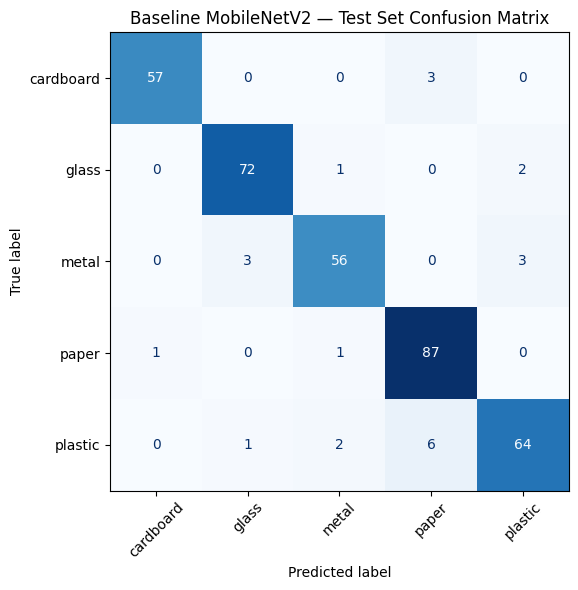

              precision    recall  f1-score   support

   cardboard      0.983     0.950     0.966        60
       glass      0.947     0.960     0.954        75
       metal      0.933     0.903     0.918        62
       paper      0.906     0.978     0.941        89
     plastic      0.928     0.877     0.901        73

    accuracy                          0.936       359
   macro avg      0.939     0.933     0.936       359
weighted avg      0.937     0.936     0.936       359



In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_labels_out, test_preds_out)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Baseline MobileNetV2 — Test Set Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# per-class metrics, useful for identifying the weakest class
from sklearn.metrics import classification_report
print(classification_report(test_labels_out, test_preds_out, target_names=class_names, digits=3))

**Brief interpretation**

Plastic ended up the weakest class this time, with the lowest f1 score at 0.901, mainly dragged down by recall (0.877), meaning a chunk of plastic images got predicted as something else rather than plastic itself. Cardboard and paper both did well (f1 above 0.94), and metal sat in the middle, with precision (0.933) noticeably higher than recall (0.903), meaning the model was fairly confident when it called something metal, but missed a few actual metal images by predicting them as another class. Glass, which was the weakest class last run, actually recovered well here, with a balanced precision and recall around 0.95. This run to run shift is mostly just normal variation from random weight initialisation, but it does suggest the model's weak points aren't fully stable across runs, and a bit more training data per class might help pin that down.

Data augmentation

**Augmentation design**

I used four augmentation techniques on the training set only:
* Random horizontal flip, since a piece of cardboard or a bottle can face either direction in a real photo, there is no fixed orientation.
* Random rotation up to 20 degrees, because photos are not always taken perfectly upright.
* Random resized crop, because the item is not always centred or filling the whole frame.
* Colour jitter on brightness, contrast, and saturation, to simulate different lighting, since a phone photo taken indoors can look quite different from one taken outdoors or under a different light bulb.

Validation and test sets were kept untouched, and only the training pipeline was changed, so the comparison with the baseline remains fair.

In [18]:
# augmentation pipeline for training data only, at least 3 techniques as required

# validation/test transforms stay exactly the same as baseline, no augmentation there
train_transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),        # flips left-right, waste items can face either way in a photo
    transforms.RandomRotation(degrees=20),          # small rotation, since photos aren't always taken perfectly upright
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # different lighting conditions in real photos
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # slight zoom/crop variation, item isn't always centered
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# reuse the same train,val,test split, just swap the transform on the train set
train_ds_aug = GarbageDataset(train_paths, train_labels, train_transform_aug)

train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)


In [19]:
# same MobileNetV2 architecture and hyperparams as baseline, only the data changes
model_aug = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
model_aug.classifier[1] = nn.Linear(model_aug.last_channel, len(class_names))
model_aug = model_aug.to(device)

criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-4)

NUM_EPOCHS = 10
epoch_times_aug = []
best_val_f1_aug = 0.0
best_ckpt_path_aug = os.path.join(PROJECT_DIR, "augmented_mobilenetv2_best.pth")

for epoch in range(NUM_EPOCHS):
    model_aug.train()
    start = time.time()
    running_loss = 0.0
    for imgs, lbls in train_loader_aug:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer_aug.zero_grad()
        outputs = model_aug(imgs)
        loss = criterion_aug(outputs, lbls)
        loss.backward()
        optimizer_aug.step()
        running_loss += loss.item()

    epoch_time = time.time() - start
    epoch_times_aug.append(epoch_time)

    val_acc, val_f1, _, _ = evaluate(model_aug, val_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | loss: {running_loss/len(train_loader_aug):.3f} "
          f"| val acc: {val_acc:.3f} | val macro-F1: {val_f1:.3f} | time: {epoch_time:.1f}s")

    # same best-checkpoint pattern as baseline, so both are compared fairly
    if val_f1 > best_val_f1_aug:
        best_val_f1_aug = val_f1
        torch.save(model_aug.state_dict(), best_ckpt_path_aug)
        print(f"  -> new best (val macro-F1: {val_f1:.3f}),  saved")

avg_epoch_time_aug = sum(epoch_times_aug) / len(epoch_times_aug)
print(f"\nAverage training time per epoch: {avg_epoch_time_aug:.1f} seconds")

# reload best checkpoint before final evaluation, same as baseline
model_aug.load_state_dict(torch.load(best_ckpt_path_aug))

val_acc_aug, val_f1_aug, _, _ = evaluate(model_aug, val_loader)
test_acc_aug, test_f1_aug, test_labels_aug, test_preds_aug = evaluate(model_aug, test_loader)

print(f"\nAugmented (best) — Validation: acc={val_acc_aug:.3f}, macro-F1={val_f1_aug:.3f}")
print(f"Augmented (best) — Test: acc={test_acc_aug:.3f}, macro-F1={test_f1_aug:.3f}")

Epoch 1/10 | loss: 0.807 | val acc: 0.852 | val macro-F1: 0.850 | time: 16.0s
  -> new best (val macro-F1: 0.850),  saved
Epoch 2/10 | loss: 0.353 | val acc: 0.899 | val macro-F1: 0.897 | time: 15.7s
  -> new best (val macro-F1: 0.897),  saved
Epoch 3/10 | loss: 0.241 | val acc: 0.913 | val macro-F1: 0.911 | time: 15.8s
  -> new best (val macro-F1: 0.911),  saved
Epoch 4/10 | loss: 0.172 | val acc: 0.927 | val macro-F1: 0.926 | time: 15.7s
  -> new best (val macro-F1: 0.926),  saved
Epoch 5/10 | loss: 0.136 | val acc: 0.919 | val macro-F1: 0.917 | time: 15.8s
Epoch 6/10 | loss: 0.099 | val acc: 0.941 | val macro-F1: 0.939 | time: 16.5s
  -> new best (val macro-F1: 0.939),  saved
Epoch 7/10 | loss: 0.111 | val acc: 0.925 | val macro-F1: 0.923 | time: 15.9s
Epoch 8/10 | loss: 0.085 | val acc: 0.936 | val macro-F1: 0.934 | time: 15.7s
Epoch 9/10 | loss: 0.068 | val acc: 0.933 | val macro-F1: 0.931 | time: 15.7s
Epoch 10/10 | loss: 0.054 | val acc: 0.953 | val macro-F1: 0.951 | time: 16.7s

Equal-cost comparison

Same number of epochs (10) and the same optimiser (Adam, lr 1e-4) were used for both settings, so the number of optimiser steps is identical, since the training set size and batch size did not change either. The only real difference is wall clock time per epoch, which comes from the extra CPU work needed for the augmentation transforms (flip, rotation, crop, colour jitter) on every image, every epoch. Both ran on the same Colab GPU session.

Total training time = training time per epoch × 10 epochs

| Setting | Accuracy | Macro-F1 | Training time per epoch (s) | Total training time (min) |
| --- | ---: | ---: | ---: | ---: |
| Baseline | 0.936 | 0.936 | 10.6 | 1.8 |
| + Augmentation | 0.939 | 0.939 | 16.0 | 2.7 |

**Short discussion**

Augmentation gave a small improvement this run, test accuracy went from 0.936 to 0.939 and macro-F1 moved the same amount. The learning curves tell a clearer story than the final numbers though, the baseline validation accuracy is quite jumpy epoch to epoch, dipping and recovering a few times, while the augmented run climbs more steadily overall and pulls ahead by the last couple of epochs. Training loss follows a similar pattern, the augmented model's loss stays noticeably higher throughout training, which makes sense since the augmented images are harder to fit exactly, but that seems to be helping it generalise rather than just memorising the training set.

The cost is training time, augmentation added about 50% more time per epoch, going from 10.6s to 16.0s, so total training time went up by roughly a minute for a fairly small accuracy gain this time round. For this dataset the trade off still feels worth it since training only takes a couple of minutes either way, but the gain was smaller than expected, and it would matter more on a bigger dataset or a longer training budget where that per epoch cost adds up.

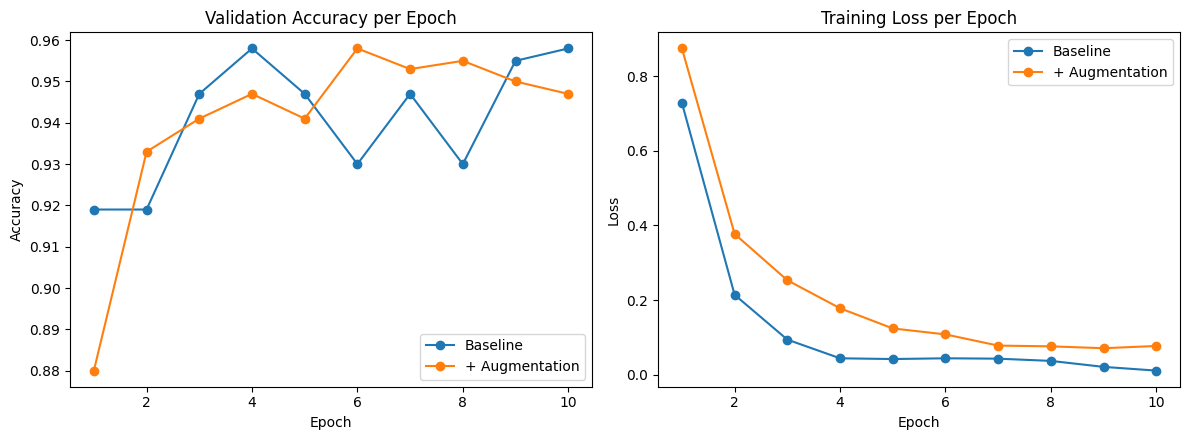

In [20]:
epochs_range = range(1, 11)

# baseline run (from the training output above)
val_acc_base = [0.919, 0.919, 0.947, 0.958, 0.947, 0.930, 0.947, 0.930, 0.955, 0.958]
train_loss_base = [0.728, 0.214, 0.094, 0.044, 0.042, 0.044, 0.043, 0.037, 0.021, 0.011]

# augmented run (from the training output above)
val_acc_aug = [0.880, 0.933, 0.941, 0.947, 0.941, 0.958, 0.953, 0.955, 0.950, 0.947]
train_loss_aug = [0.874, 0.377, 0.253, 0.178, 0.124, 0.108, 0.078, 0.076, 0.071, 0.077]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, val_acc_base, marker='o', label='Baseline')
axes[0].plot(epochs_range, val_acc_aug, marker='o', label='+ Augmentation')
axes[0].set_title("Validation Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs_range, train_loss_base, marker='o', label='Baseline')
axes[1].plot(epochs_range, train_loss_aug, marker='o', label='+ Augmentation')
axes[1].set_title("Training Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

Pipeline profiling

**Slowest step and mitigation**

Compute (forward and backward pass) took 6.19s, data loading took 4.81s, so compute is a heavier but not by a huge margin. Since num_workers is already set to 2, bumping it up to 4 would probably help close that data loading gap a bit, since more images get prefetched in the background while the GPU is busy instead of waiting. For the compute side, a bigger batch size would use the GPU more efficiently, or mixed precision training could cut the time per step too. That said, the whole epoch only takes around 11 seconds on a dataset this small, so this isn't really a bottleneck worth spending more time fixing here.

In [21]:
# quick timing check to see which part of the pipeline is actually slow
data_time = 0.0
compute_time = 0.0

model.train()
t0 = time.time()
for imgs, lbls in train_loader:
    data_time += time.time() - t0  # time to get this batch ready

    t1 = time.time()
    imgs, lbls = imgs.to(device), lbls.to(device)
    optimizer.zero_grad()
    outputs = model(imgs)
    loss = criterion(outputs, lbls)
    loss.backward()
    optimizer.step()
    compute_time += time.time() - t1  # time to actually train on this batch

    t0 = time.time()  # start of next batch's data loading

print(f"Data loading time: {data_time:.2f}s")
print(f"Compute time (forward+backward): {compute_time:.2f}s")
print(f"Total: {data_time + compute_time:.2f}s")

Data loading time: 4.78s
Compute time (forward+backward): 5.79s
Total: 10.57s


Failure analysis

**Observed pattern**

Two error patterns show up in this 6 images.
First, shiny or reflective stuff tends to get predicted as metal no matter what it actually is, glass jars and lids and even a crumpled plastic wrapper all got called metal, probably because the model is picking up on shininess rather than the real material.
Second, paper and cardboard get mixed up when there is a lot of printed content or a glossy photo on the surface, a cardboard box with a big printed picture got called paper, and a glossy magazine cover got called cardboard.
So in both cases it looks like the model is going off how shiny or how printed the surface looks, instead of the actual texture of the material underneath.

Total misclassified: 22 out of 359


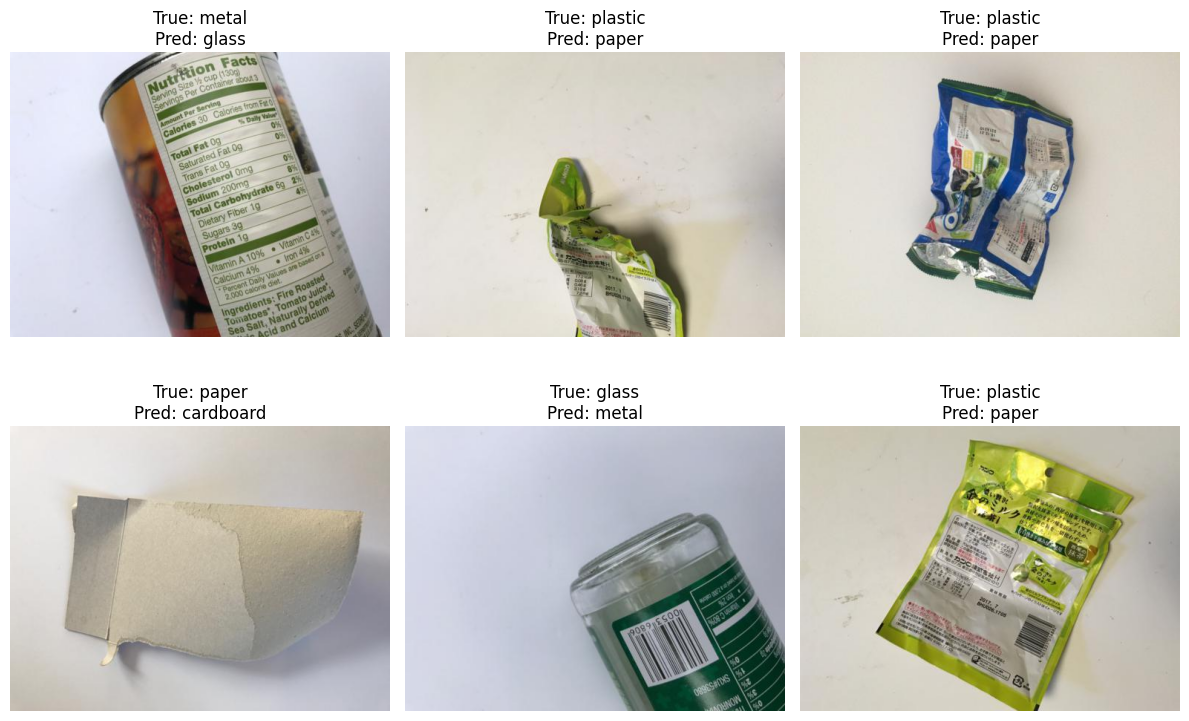

In [22]:
# find which test images the model got wrong
misclassified_idx = []
for i in range(len(test_labels_aug)):
    if test_labels_aug[i] != test_preds_aug[i]:
        misclassified_idx.append(i)

print("Total misclassified:", len(misclassified_idx), "out of", len(test_labels_aug))

# just take the first 6 of them
show_idx = misclassified_idx[:6]

# plot them in a 2x3 grid
plt.figure(figsize=(12, 8))

for i in range(len(show_idx)):
    idx = show_idx[i]
    img = Image.open(test_paths[idx]).convert("RGB")

    true_cls = class_names[test_labels_aug[idx]]
    pred_cls = class_names[test_preds_aug[idx]]

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title("True: " + true_cls + "\nPred: " + pred_cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

New-domain test set

**New-domain collection protocol**

30 of the 35 images (glass, metal, paper, plastic, 7 each of 4 classes) were taken personally using a phone camera in a home kitchen, on natural surfaces like the counter, table, and floor. The remaining 5 images (cardboard) were collected from online sources, using varied search queries to avoid overlapping with the original training dataset. All images were newly collected for this task and were not used during training, validation, or model selection. Class definitions match Task 1.1 exactly, and the set is balanced with 7 images per class, 35 total, meeting the minimum required.

| Aspect | Original test set | New-domain test set |
| --- | --- | --- |
| Source | Kaggle Garbage Classification dataset (TrashNet-based) | Own phone photos (4 classes) + web images (cardboard) |
| Class counts | Cardboard 60, Glass 75, Metal 62, Paper 89, Plastic 73 | 7 per class, 35 total |
| Background | Plain white/studio background | Natural kitchen surfaces (counter, table, floor) |
| Lighting | Even, studio-style lighting | Regular indoor room lighting, less controlled |
| Viewpoint / scale | Item centred, top-down or fixed angle | Varied angles and distances, phone-camera framing |
| Other relevant differences | Single clean item, no clutter | Some clutter/context visible around the item (typical of a real kitchen) |

cardboard : 7 images
glass : 7 images
metal : 7 images
paper : 7 images
plastic : 7 images
Total new-domain images: 35


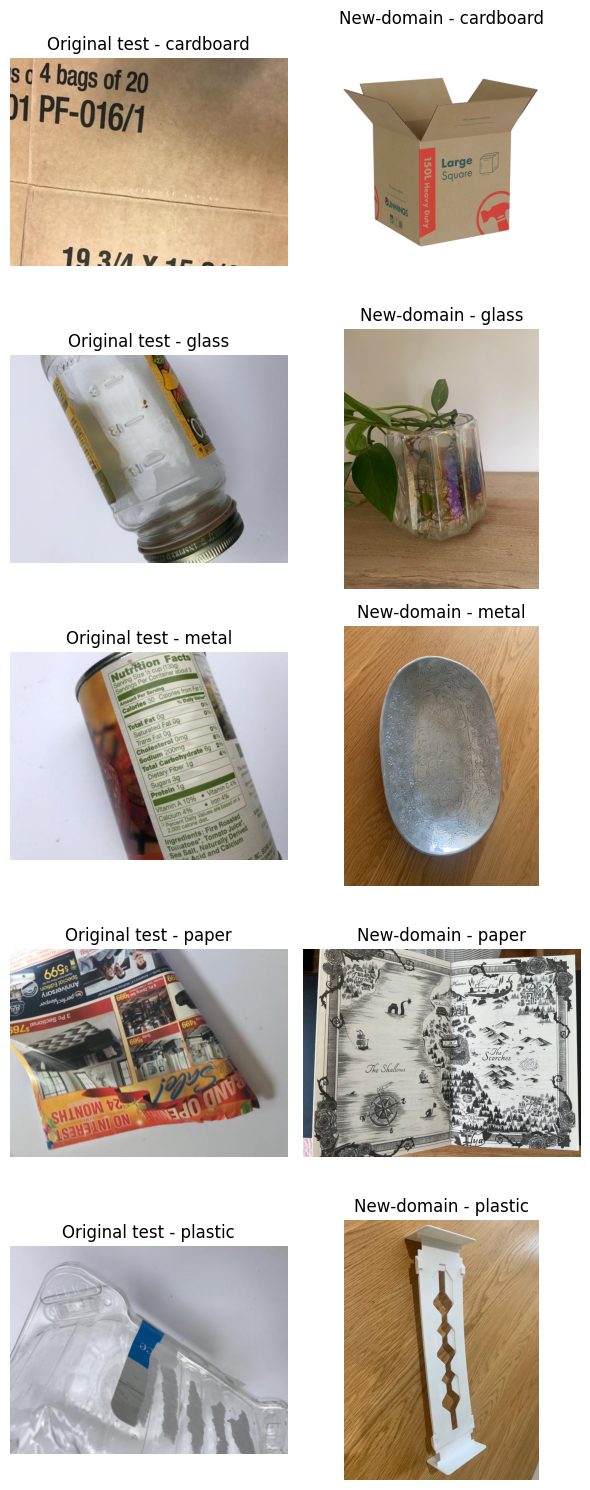

In [23]:
# ---- 1. load new-domain images and count how many per class ----
new_domain_dir = os.path.join(PROJECT_DIR, "new_domain_test")

new_domain_paths = []
new_domain_labels = []

for cls in class_names:
    cls_dir = os.path.join(new_domain_dir, cls)
    files = os.listdir(cls_dir)
    print(cls, ":", len(files), "images")

    for fname in files:
        full_path = os.path.join(cls_dir, fname)
        new_domain_paths.append(full_path)
        new_domain_labels.append(class_to_idx[cls])

print("Total new-domain images:", len(new_domain_paths))

# ---- 2. show one original image and one new-domain image, per class ----
plt.figure(figsize=(6, 3 * len(class_names)))

plot_num = 1
for cls in class_names:
    cls_idx = class_to_idx[cls]

    # find one original test image for this class
    orig_path = None
    for i in range(len(test_paths)):
        if test_labels[i] == cls_idx:
            orig_path = test_paths[i]
            break

    # find one new-domain image for this class
    new_path = None
    for i in range(len(new_domain_paths)):
        if new_domain_labels[i] == cls_idx:
            new_path = new_domain_paths[i]
            break

    # plot original on the left
    plt.subplot(len(class_names), 2, plot_num)
    plt.imshow(Image.open(orig_path).convert("RGB"))
    plt.title("Original test - " + cls)
    plt.axis('off')
    plot_num += 1

    # plot new-domain on the right
    plt.subplot(len(class_names), 2, plot_num)
    plt.imshow(Image.open(new_path).convert("RGB"))
    plt.title("New-domain - " + cls)
    plt.axis('off')
    plot_num += 1

plt.tight_layout()
plt.show()

In [24]:
# DataLoader for the new-domain set
new_domain_ds = GarbageDataset(new_domain_paths, new_domain_labels, transform)  # same transform as val/test, no augmentation
new_domain_loader = DataLoader(new_domain_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# evaluate the current best model (augmented, from Task 2) on both domains
orig_acc_before, orig_f1_before, _, _ = evaluate(model_aug, test_loader)
new_acc_before, new_f1_before, new_labels_before, new_preds_before = evaluate(model_aug, new_domain_loader)

print("BEFORE targeted improvement")
print(f"Original test  — acc: {orig_acc_before:.3f}, macro-F1: {orig_f1_before:.3f}")
print(f"New-domain     — acc: {new_acc_before:.3f}, macro-F1: {new_f1_before:.3f}")

BEFORE targeted improvement
Original test  — acc: 0.939, macro-F1: 0.939
New-domain     — acc: 0.400, macro-F1: 0.357


Targeted improvement

**Chosen intervention**

Based on Task 3.1's failure patterns (shiny/reflective surfaces confused as metal, printed/glossy surfaces confusing paper and cardboard) combined with the large accuracy drop measured on the new-domain set, the model was retrained with a stronger, more realistic augmentation pipeline. Rotation was widened (20 to 30 degrees), colour jitter was widened (0.2 to 0.4 on brightness/contrast/saturation) to better cover varied indoor lighting, the crop scale range was widened (0.8 to 0.6) to cover different distances, and random perspective distortion was added to simulate the off-angle, handheld phone photography seen in the new-domain set, none of which the original studio-style training images had. Architecture (MobileNetV2, pretrained) and all other training settings stayed the same as Task 2, only the augmentation pipeline changed, so the comparison isolates its effect.

| Model variant | Original test accuracy | Original test macro-F1 | New-domain accuracy | New-domain macro-F1 |
| --- | ---: | ---: | ---: | ---: |
| Before targeted improvement | 0.939 | 0.939 | 0.400 | 0.357 |
| After targeted improvement | 0.925 | 0.924 | 0.629 | 0.614 |

**Final discussion**

The weakness found in Task 3.1 and 3.2 was that the model, since it only saw clean studio style images during training, did not generalise well to real photos with natural backgrounds, different lighting, and off angle framing. New domain macro F1 was only 0.357 before the change, well below the 0.939 seen on the original test set. This gap was the clearest sign that the model had picked up shortcuts tied to how the training images looked rather than learning the actual material properties we wanted it to.

So the change made was to widen the augmentation pipeline in a way that matched the kind of variation seen in the new domain photos. More rotation, stronger colour jitter for lighting, a wider crop range for distance, and perspective distortion was also added for camera angle. This was expected to help because showing the model more visual variation during training should make it rely less on the narrow, clean conditions of the original dataset.

After retraining, new domain macro F1 rose to 0.614, a solid improvement, while original test macro F1 dropped slightly, from 0.939 to 0.924. So the change clearly helped the model generalise better to the new domain, at a small cost on the original domain this time, rather than no cost at all. That small drop is worth being upfront about, it is possible the stronger augmentation made training slightly harder overall, trading a little original domain performance for a meaningful gain elsewhere. Even accounting for that, 0.614 is still well below the 0.924 on the original domain, so a real generalisation gap remains. Augmentation narrowed it but did not close it, and this is probably because synthetic variation can only go so far, it is not the same as training on actual examples from the target domain.

In [25]:
# stronger augmentation
# trying to fix the domain gap we saw, different angles, lighting, more realistic
train_transform_strong = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),  # made this bigger than before (was 20), phone pics are never perfectly straight
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),  # new one, tries to copy the weird angles you get holding a phone
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),  # made this bigger too (was 0.2), kitchen lighting is not consistent
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),  # bigger range than before (was 0.8), photos are taken from different distances
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds_strong = GarbageDataset(train_paths, train_labels, train_transform_strong)
train_loader_strong = DataLoader(train_ds_strong, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# new model again, same as before, just MobileNetV2 pretrained
model_final = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
model_final.classifier[1] = nn.Linear(model_final.last_channel, len(class_names))
model_final = model_final.to(device)

criterion_final = nn.CrossEntropyLoss()
optimizer_final = optim.Adam(model_final.parameters(), lr=1e-4)

NUM_EPOCHS = 10
best_val_f1_final = 0.0
best_ckpt_path_final = os.path.join(PROJECT_DIR, "final_mobilenetv2_best.pth")

# same training loop as the other two times, just using train_loader_strong now
for epoch in range(NUM_EPOCHS):
    model_final.train()
    running_loss = 0.0

    for imgs, lbls in train_loader_strong:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer_final.zero_grad()
        outputs = model_final(imgs)
        loss = criterion_final(outputs, lbls)
        loss.backward()
        optimizer_final.step()
        running_loss += loss.item()

    val_acc, val_f1, _, _ = evaluate(model_final, val_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | loss: {running_loss/len(train_loader_strong):.3f} | val acc: {val_acc:.3f} | val macro-F1: {val_f1:.3f}")

    # only save if this epoch is better than what we had, same trick as before
    if val_f1 > best_val_f1_final:
        best_val_f1_final = val_f1
        torch.save(model_final.state_dict(), best_ckpt_path_final)
        print("  -> new best (val macro-F1:", val_f1, "), saved")

# load the best version we saved, not just whatever epoch 10 ended up being
model_final.load_state_dict(torch.load(best_ckpt_path_final))

orig_acc_after, orig_f1_after, _, _ = evaluate(model_final, test_loader)
new_acc_after, new_f1_after, new_labels_after, new_preds_after = evaluate(model_final, new_domain_loader)

print("AFTER targeted improvement")
print("Original test  — acc:", orig_acc_after, "macro-F1:", orig_f1_after)
print("New-domain     — acc:", new_acc_after, "macro-F1:", new_f1_after)

Epoch 1/10 | loss: 0.879 | val acc: 0.832 | val macro-F1: 0.830
  -> new best (val macro-F1: 0.8298809796167379 ), saved
Epoch 2/10 | loss: 0.433 | val acc: 0.874 | val macro-F1: 0.874
  -> new best (val macro-F1: 0.8743689135726134 ), saved
Epoch 3/10 | loss: 0.323 | val acc: 0.885 | val macro-F1: 0.883
  -> new best (val macro-F1: 0.883308501070216 ), saved
Epoch 4/10 | loss: 0.262 | val acc: 0.897 | val macro-F1: 0.894
  -> new best (val macro-F1: 0.8942534990956006 ), saved
Epoch 5/10 | loss: 0.209 | val acc: 0.894 | val macro-F1: 0.892
Epoch 6/10 | loss: 0.164 | val acc: 0.911 | val macro-F1: 0.909
  -> new best (val macro-F1: 0.9088546760632988 ), saved
Epoch 7/10 | loss: 0.133 | val acc: 0.905 | val macro-F1: 0.903
Epoch 8/10 | loss: 0.107 | val acc: 0.911 | val macro-F1: 0.908
Epoch 9/10 | loss: 0.107 | val acc: 0.925 | val macro-F1: 0.921
  -> new best (val macro-F1: 0.9208213504683705 ), saved
Epoch 10/10 | loss: 0.109 | val acc: 0.919 | val macro-F1: 0.918
AFTER targeted imp